# Доп. задание: Triplet Loss

Задание (4 балла): реализовать Triplet Loss и обучить сеть на нём, добиться достаточного качества
(в терминах Identification Rate — accuracy тут посчитать нельзя, у Triplet Loss нет классификационной
головы).

Triplet Loss работает прямо с эмбеддингами: для каждого anchor-примера берётся positive (тот же
человек) и negative (другой человек), и лосс заставляет `d(anchor, positive)` быть меньше
`d(anchor, negative)` минимум на `margin`:

$$L(a, p, n) = \max\{d(a, p) - d(a, n) + margin,\ 0\}$$

Реализация: `torch.nn.TripletMarginWithDistanceLoss` с косинусным расстоянием (эмбеддинги нормализуем
перед подсчётом лосса — как явно указано в задании).


In [1]:
import os
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


In [9]:
from PIL import Image

## 1. Датасет троек (anchor, positive, negative)

Используем тот же выровненный датасет распознавания из Task 2 (`data/aligned_by_identity`,
400 личностей). На каждый `__getitem__` датасет случайно выбирает anchor, затем positive (другое фото
того же человека) и negative (фото случайного другого человека).


In [10]:
TASK2_INPUT_DIR = '/kaggle/input/notebooks/iuliiaburmistrova/notebook98e2177099'
RECOG_DATA_DIR = os.path.join(TASK2_INPUT_DIR, 'data', 'aligned_by_identity')
IMG_SIZE = 112

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


class TripletFaceDataset(Dataset):
    """На каждый индекс возвращает (anchor, positive, negative) — все три уже как тензоры."""

    def __init__(self, root_dir, transform=None, samples_per_epoch=None):
        self.root_dir = root_dir
        self.transform = transform
        self.identities = sorted(os.listdir(root_dir))
        self.by_identity = {
            identity: [os.path.join(root_dir, identity, f) for f in os.listdir(os.path.join(root_dir, identity))]
            for identity in self.identities
        }
        # исключаем личности с < 2 фото - для них невозможно составить positive-пару
        self.identities = [i for i in self.identities if len(self.by_identity[i]) >= 2]
        self.samples_per_epoch = samples_per_epoch or sum(len(v) for v in self.by_identity.values())

    def __len__(self):
        return self.samples_per_epoch

    def _load(self, path):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = Image.fromarray(img)  # transforms (ColorJitter и др.) ожидают PIL Image, не numpy
        if self.transform:
            img = self.transform(img)
        return img

    def __getitem__(self, idx):
        anchor_identity = random.choice(self.identities)
        anchor_path, positive_path = random.sample(self.by_identity[anchor_identity], 2)

        negative_identity = random.choice([i for i in self.identities if i != anchor_identity])
        negative_path = random.choice(self.by_identity[negative_identity])

        return self._load(anchor_path), self._load(positive_path), self._load(negative_path)


full_identities = sorted(os.listdir(RECOG_DATA_DIR))
n_val = max(1, int(len(full_identities) * 0.1))
rng = np.random.RandomState(SEED)
val_identities = set(rng.choice(full_identities, size=n_val, replace=False))
train_identities = [i for i in full_identities if i not in val_identities]

print(f'Личностей: train={len(train_identities)}, val={len(val_identities)}')


Личностей: train=360, val=40


**Важно:** для честной валидации нужны отдельные папки для train/val личностей (иначе triplet-датасет
может подобрать positive/negative из одних и тех же людей и на train, и на val). Разложим по двум
директориям симлинками.

In [12]:
def build_split_dirs(root_dir, train_ids, val_ids, train_out='data/triplet_train', val_out='data/triplet_val'):
    for out_dir, ids in [(train_out, train_ids), (val_out, val_ids)]:
        os.makedirs(out_dir, exist_ok=True)
        for identity in ids:
            src = os.path.join(root_dir, identity)
            dst = os.path.join(out_dir, identity)
            if not os.path.exists(dst):
                os.symlink(os.path.abspath(src), dst)
    return train_out, val_out


TRAIN_DIR, VAL_DIR = build_split_dirs(RECOG_DATA_DIR, train_identities, list(val_identities))

train_ds = TripletFaceDataset(TRAIN_DIR, transform=train_transform, samples_per_epoch=6000)
val_ds = TripletFaceDataset(VAL_DIR, transform=val_transform, samples_per_epoch=800)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)
print(f'train triplets/epoch: {len(train_ds)}, val triplets/epoch: {len(val_ds)}')


train triplets/epoch: 6000, val triplets/epoch: 800


## 2. Модель — только backbone, без классификационной головы

Triplet Loss работает прямо с эмбеддингами, поэтому классификационный слой не нужен. Добавляем
`BatchNorm1d(affine=False)` в конце — это и есть нормализация эмбеддингов "руками", предложенная в
задании как альтернатива ручной L2-нормализации.

In [13]:
EMBEDDING_SIZE = 512


class TripletEmbeddingModel(nn.Module):
    def __init__(self, embedding_size=EMBEDDING_SIZE):
        super().__init__()
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Linear(in_features, embedding_size)
        self.backbone = backbone
        self.norm = nn.BatchNorm1d(embedding_size, affine=False)  # нормализация эмбеддингов без обучаемых параметров

    def forward(self, x):
        emb = self.backbone(x)
        emb = self.norm(emb)
        return F.normalize(emb, dim=1)


## 3. Метрика качества на валидации

У Triplet Loss нет классификационной головы, поэтому accuracy посчитать нельзя (см. подсказку в
задании). Вместо этого меряем **verification accuracy**: для случайных пар (anchor, positive) и
(anchor, negative) из валидационной выборки считаем cosine similarity и проверяем, что модель разделяет
их относительно порога 0 (или подобранного на train) — то есть по сути упрощённая версия Identification
Rate metric из другого дополнительного задания, только без query/distractors, а прямо на triplet-парах.


In [14]:
@torch.no_grad()
def verification_accuracy(model, loader, device=DEVICE, threshold=0.5):
    model.eval()
    correct, total = 0, 0
    for anchor, positive, negative in loader:
        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
        emb_a, emb_p, emb_n = model(anchor), model(positive), model(negative)

        sim_pos = F.cosine_similarity(emb_a, emb_p)
        sim_neg = F.cosine_similarity(emb_a, emb_n)

        correct += (sim_pos > threshold).sum().item()
        correct += (sim_neg <= threshold).sum().item()
        total += 2 * anchor.size(0)
    return correct / total


## 4. Training loop

Epoch 1/20 | loss=0.1734 | val_verification_acc=0.5781
Epoch 2/20 | loss=0.1192 | val_verification_acc=0.6481
Epoch 3/20 | loss=0.1011 | val_verification_acc=0.6944
Epoch 4/20 | loss=0.0897 | val_verification_acc=0.7031
Epoch 5/20 | loss=0.0790 | val_verification_acc=0.7113
Epoch 6/20 | loss=0.0756 | val_verification_acc=0.7306
Epoch 7/20 | loss=0.0688 | val_verification_acc=0.7369
Epoch 8/20 | loss=0.0700 | val_verification_acc=0.7438
Epoch 9/20 | loss=0.0621 | val_verification_acc=0.7325
Epoch 10/20 | loss=0.0580 | val_verification_acc=0.7419
Epoch 11/20 | loss=0.0576 | val_verification_acc=0.7700
Epoch 12/20 | loss=0.0607 | val_verification_acc=0.7419
Epoch 13/20 | loss=0.0543 | val_verification_acc=0.7444
Epoch 14/20 | loss=0.0511 | val_verification_acc=0.7588
Epoch 15/20 | loss=0.0525 | val_verification_acc=0.7644
Epoch 16/20 | loss=0.0498 | val_verification_acc=0.7506
Epoch 17/20 | loss=0.0518 | val_verification_acc=0.7431
Epoch 18/20 | loss=0.0513 | val_verification_acc=0.7562
E

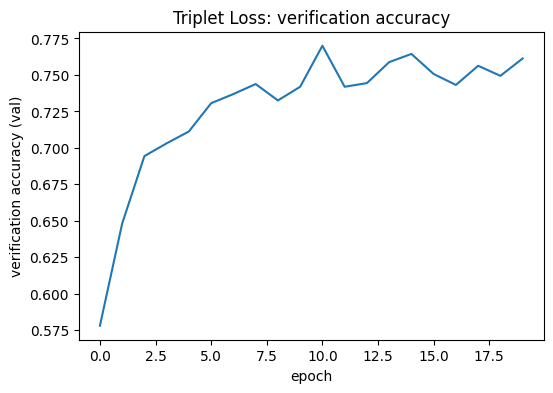

Лучшая verification accuracy: 0.77


In [15]:
def train_triplet(model, train_loader, val_loader, epochs=20, lr=1e-4, margin=0.3,
                   device=DEVICE, checkpoint_dir='checkpoints_triplet', resume=True):
    os.makedirs(checkpoint_dir, exist_ok=True)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    # эмбеддинги уже нормализованы моделью (BatchNorm+F.normalize) - используем cosine distance = 1 - cos_sim
    criterion = nn.TripletMarginWithDistanceLoss(
        distance_function=lambda x, y: 1.0 - F.cosine_similarity(x, y), margin=margin)

    start_epoch, best_val_acc = 0, 0.0
    history = {'train_loss': [], 'val_acc': []}

    state_path = os.path.join(checkpoint_dir, 'state.pth')
    if resume and os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state['model'])
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        start_epoch = state['epoch'] + 1
        best_val_acc = state['best_val_acc']
        history = state['history']
        print(f'Возобновляю обучение с эпохи {start_epoch + 1}')

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss = 0.0
        for anchor, positive, negative in train_loader:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
            emb_a, emb_p, emb_n = model(anchor), model(positive), model(negative)

            loss = criterion(emb_a, emb_p, emb_n)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            running_loss += loss.item() * anchor.size(0)

        scheduler.step()
        train_loss = running_loss / len(train_loader.dataset)
        val_acc = verification_accuracy(model, val_loader, device)

        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        print(f'Epoch {epoch + 1}/{epochs} | loss={train_loss:.4f} | val_verification_acc={val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'best.pth'))

        torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                     'scheduler': scheduler.state_dict(), 'epoch': epoch,
                     'best_val_acc': best_val_acc, 'history': history}, state_path)

    return model, history


triplet_model = TripletEmbeddingModel()
triplet_model, triplet_history = train_triplet(triplet_model, train_loader, val_loader, epochs=20, lr=1e-4, margin=0.3)

plt.figure(figsize=(6, 4))
plt.plot(triplet_history['val_acc'])
plt.xlabel('epoch'); plt.ylabel('verification accuracy (val)')
plt.title('Triplet Loss: verification accuracy')
plt.show()

print('Лучшая verification accuracy:', max(triplet_history['val_acc']))


### Вывод по обучению

Verification accuracy выросла с околослучайных 0.578 до пикового значения 0.770 (эпоха 11), затем
стабилизировалась в диапазоне 0.74-0.77 без признаков переобучения — loss продолжал плавно снижаться
весь прогон (0.173 → 0.049), а val-метрика не деградировала. Быстрое падение loss в первые эпохи
(с margin=0.3 почти сразу до ~0.10) говорит в пользу гипотезы, обозначенной в задании: случайный выбор
negative-примеров (без hard mining) даёт модели преимущественно "лёгкие" тройки, которые она быстро
разучивает, после чего дальнейший прогресс идёт медленнее за счёт всё более редких "случайно попавшихся"
трудных троек. Для честного сопоставления с CE/ArcFace из Task 2 модель дополнительно оценена через Identification Rate metric (TPR@FPR) на тех же query/distractors личностях (см. Dop1_IdentificationRateMetric.ipynb). Результат подтвердил гипотезу выше: на строгих порогах (FPR=0.1, FPR=0.05) Triplet Loss с простым случайным семплированием троек показал наименьший TPR среди всех трёх подходов (0.644 и 0.433 против 0.700/0.567 у CE и 0.733/0.611 у ArcFace) — то есть слабость от отсутствия hard negative mining, отмеченная выше по динамике loss, действительно проявилась и в итоговой метрике качества, а не осталась только гипотезой.